# Patch-level Text-Similarity Logit Lens
Compares what CLIP, SigLIP1, and SigLIP2 'see' at each patch and layer by projecting
intermediate activations into the shared text-vision embedding space and finding the
most similar text label per patch.

Unlike the ImageNet emoji lens (which needs a classifier head), this works for any
vision-language model with a text encoder.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont
import requests
from torchvision import transforms
from transformers import CLIPModel, CLIPTokenizer, SiglipModel, AutoTokenizer
from vit_prisma.models.model_loader import load_hooked_model

device = 'cpu'
LAYERS = [0, 4, 8, 11]
N_PATCHES = 14

/Volumes/enigma/bluedot_project/ViT-Prisma/.venv/lib/python3.11/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




## Image

In [2]:
# img = Image.open(requests.get(
#     'https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_dog.jpg/320px-Cute_dog.jpg',
#     stream=True).raw).convert('RGB')
img = Image.open("cat_dog.png")

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
x = preprocess(img).unsqueeze(0)
img_224 = img.resize((224, 224))

## Labels

In [ ]:
LABELS = [
    ('🐕', 'dog',        'a photo of a dog',                        '#8B4513'),
    ('🐈', 'cat',        'a photo of a cat',                        '#808080'),
    ('👁', 'eye',        'a close-up of an eye',                    '#4169E1'),
    ('👄', 'nose/mouth', 'a close-up of a nose or mouth',           '#DC143C'),
    ('🟧', 'fur',        'animal fur texture',                      '#D2691E'),
    ('🌿', 'bg',         'background, grass, sky, or plain surface','#A8C8A0'),
    ('🐾', 'paw',        'an animal paw or leg',                    '#556B2F'),
]
label_emojis = [l[0] for l in LABELS]
label_names  = [l[1] for l in LABELS]
label_texts  = [l[2] for l in LABELS]
label_colors = [l[3] for l in LABELS]
print('Labels:', [f'{e} {n}' for e, n in zip(label_emojis, label_names)])

## Helper functions

In [4]:
def get_text_embeddings_clip(model, tokenizer, texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True)
    with torch.no_grad():
        embs = model.get_text_features(**inputs)
    return embs / embs.norm(dim=-1, keepdim=True)

def get_text_embeddings_siglip(model, tokenizer, texts):
    inputs = tokenizer(texts, return_tensors='pt', padding='max_length', max_length=64)
    with torch.no_grad():
        embs = model.get_text_features(**inputs)
    return embs / embs.norm(dim=-1, keepdim=True)

def patch_label_indices(activations, text_embs, ln, projection=None):
    acts = ln(activations.float())
    if projection is not None:
        acts = acts @ projection.T
    acts = acts / acts.norm(dim=-1, keepdim=True)
    return (acts @ text_embs.T).argmax(dim=-1)

def _hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

# Load system emoji font once (Apple Color Emoji on macOS, fallback to None)
_EMOJI_FONT = None
for _fp in ['/System/Library/Fonts/Apple Color Emoji.ttc',
            '/System/Library/Fonts/Supplemental/NotoEmoji.ttf']:
    try:
        _EMOJI_FONT = ImageFont.truetype(_fp, 20)
        break
    except OSError:
        pass

def draw_patch_grid(ax, img, indices, colors, emojis, n=14, title='', scale=4):
    ps = 224 // n
    sz = 224 * scale
    ps_s = ps * scale
    canvas = img.resize((sz, sz), Image.LANCZOS).convert('RGBA')
    overlay = Image.new('RGBA', (sz, sz), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    font = ImageFont.truetype(_EMOJI_FONT.path, ps_s // 2) if _EMOJI_FONT else None
    for i, idx in enumerate(indices.tolist()):
        row, col = divmod(i, n)
        r, g, b = _hex_to_rgb(colors[idx])
        draw.rectangle([col*ps_s, row*ps_s, (col+1)*ps_s - 1, (row+1)*ps_s - 1],
                       fill=(r, g, b, 128))
        if font:
            draw.text((col*ps_s + ps_s // 2, row*ps_s + ps_s // 2),
                      emojis[idx], font=font, anchor='mm', embedded_color=True)
    result = Image.alpha_composite(canvas, overlay).convert('RGB')
    ax.imshow(result)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

## Load models and text encoders

In [5]:
print('Loading CLIP...')
clip_vision = load_hooked_model('openai/clip-vit-base-patch16', device=device)
clip_full   = CLIPModel.from_pretrained('openai/clip-vit-base-patch16')
clip_tok    = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch16')
clip_proj   = clip_full.visual_projection.weight.detach()  # [512, 768]

print('Loading SigLIP1...')
siglip1_vision = load_hooked_model('google/siglip-base-patch16-224', device=device)
siglip1_full   = SiglipModel.from_pretrained('google/siglip-base-patch16-224')
siglip1_tok    = AutoTokenizer.from_pretrained('google/siglip-base-patch16-224', use_fast=False)

print('Loading SigLIP2...')
siglip2_vision = load_hooked_model('google/siglip2-base-patch16-224', device=device)
siglip2_full   = SiglipModel.from_pretrained('google/siglip2-base-patch16-224')
siglip2_tok    = AutoTokenizer.from_pretrained('google/siglip2-base-patch16-224', use_fast=False)

for m in [clip_vision, siglip1_vision, siglip2_vision]:
    m.eval()
print('Done.')

2026-06-26 00:40:52 WARNING:root: Model 'openai/clip-vit-base-patch16' is not in the lists of models passing or failing tests. Unclear status. You may want to check that the HookedViT matches the original model under tests/test_loading_clip.py.
2026-06-26 00:40:52 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


Loading CLIP...


2026-06-26 00:40:52 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /openai/clip-vit-base-patch16/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:52 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/openai/clip-vit-base-patch16/57c216476eefef5ab752ec549e440a49ae4ae5f3/config.json HTTP/1.1" 200 0
2026-06-26 00:40:52 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /openai/clip-vit-base-patch16/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:52 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/openai/clip-vit-base-patch16/57c216476eefef5ab752ec549e440a49ae4ae5f3/config.json HTTP/1.1" 200 0
2026-06-26 00:40:53 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /openai/clip-vit-base-patch16/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:53 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/openai/clip-vit

Loading SigLIP1...
ln_pre not set


2026-06-26 00:40:55 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:55 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip-base-patch16-224/7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed/config.json HTTP/1.1" 200 0
2026-06-26 00:40:55 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:55 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip-base-patch16-224/7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed/config.json HTTP/1.1" 200 0
2026-06-26 00:40:55 INFO:root: Filling in 1 missing keys with default initialization
2026-06-26 00:40:56 INFO:root: Loaded pretrained model google/siglip-base-patch16-224 into HookedTransformer
2026-06-26 00:40:56 DEBUG:urllib3.connectionpool: https://huggingface.co:443

Loading SigLIP2...
ln_pre not set


2026-06-26 00:40:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip2-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json HTTP/1.1" 200 0
2026-06-26 00:40:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip2-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-26 00:40:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json HTTP/1.1" 200 0
2026-06-26 00:40:57 INFO:root: Filling in 1 missing keys with default initialization
2026-06-26 00:40:58 INFO:root: Loaded pretrained model google/siglip2-base-patch16-224 into HookedTransformer
2026-06-26 00:40:58 DEBUG:urllib3.connectionpool: https://huggingface.c

Done.


## Compute text embeddings

In [6]:
clip_text    = get_text_embeddings_clip(clip_full, clip_tok, label_texts)
siglip1_text = get_text_embeddings_siglip(siglip1_full, siglip1_tok, label_texts)
siglip2_text = get_text_embeddings_siglip(siglip2_full, siglip2_tok, label_texts)
print(f'CLIP: {clip_text.shape}, SigLIP1: {siglip1_text.shape}, SigLIP2: {siglip2_text.shape}')

CLIP: torch.Size([7, 512]), SigLIP1: torch.Size([7, 768]), SigLIP2: torch.Size([7, 768])


## Cache activations

In [7]:
with torch.no_grad():
    _, cache_clip = clip_vision.run_with_cache(x)
    _, cache_s1   = siglip1_vision.run_with_cache(x)
    _, cache_s2   = siglip2_vision.run_with_cache(x)

## Logit lens comparison
Each patch is coloured and labelled by the text concept most similar to its intermediate activation.

2026-06-26 00:41:02 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-26 00:41:02 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-26 00:41:02 DEBUG:matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-26 00:41:02 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/Volumes/enigma/bluedot_project/ViT-Prisma/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Bold.ttf', index=0, name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-06-26 00:41:02 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/Volumes/enigma/bluedot_project/ViT-Prisma/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/LastResortHE-Regular.ttf', index=0, name='Last Resort High-Efficiency', style='norma

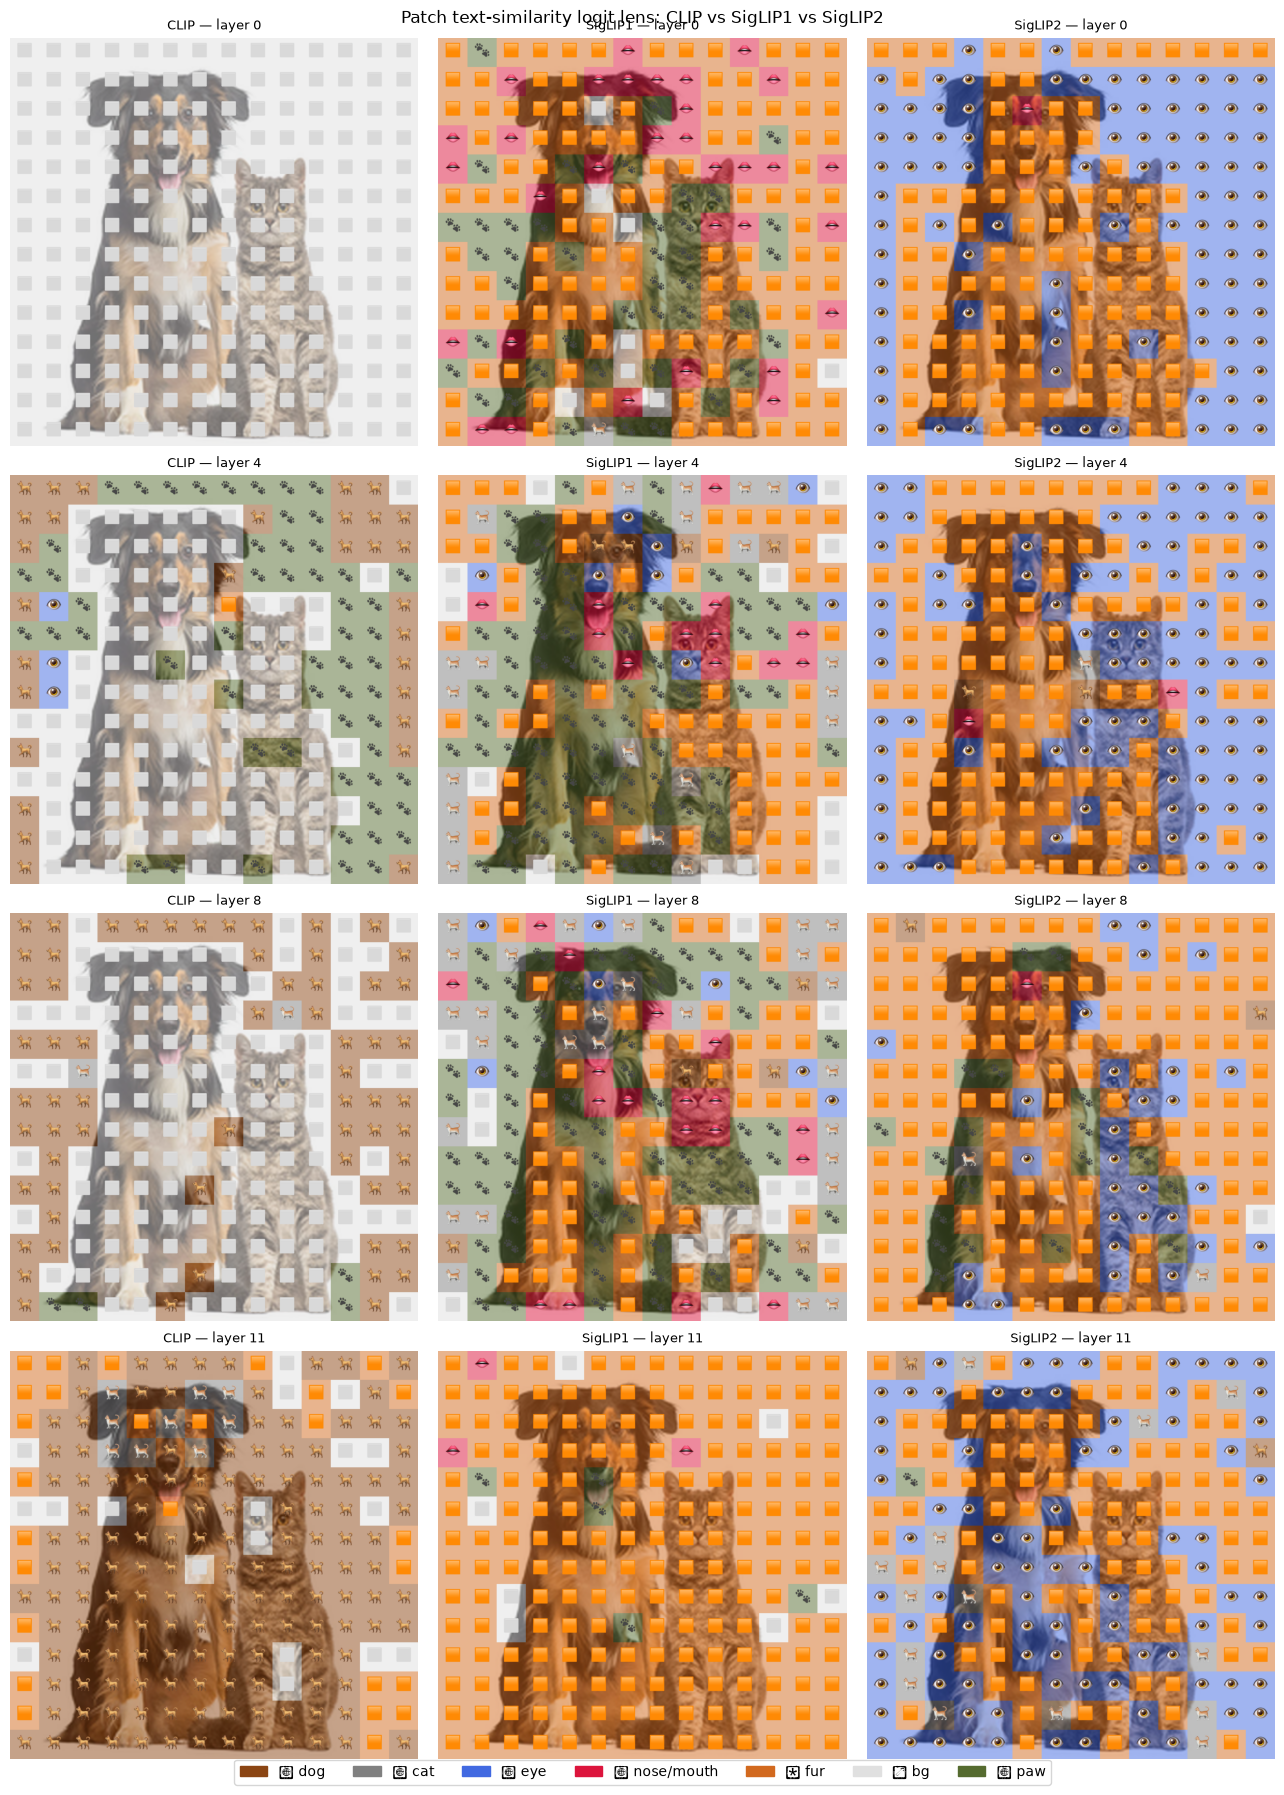

In [8]:
fig, axes = plt.subplots(len(LAYERS), 3, figsize=(13, 4.5 * len(LAYERS)))

for row, layer in enumerate(LAYERS):
    key = f'blocks.{layer}.hook_resid_post'

    acts_clip = cache_clip[key][0][1:]  # drop CLS token
    idx_clip  = patch_label_indices(acts_clip, clip_text,
                                    ln=clip_vision.ln_final, projection=clip_proj)

    acts_s1 = cache_s1[key][0]
    idx_s1  = patch_label_indices(acts_s1, siglip1_text, ln=siglip1_vision.ln_final)

    acts_s2 = cache_s2[key][0]
    idx_s2  = patch_label_indices(acts_s2, siglip2_text, ln=siglip2_vision.ln_final)

    draw_patch_grid(axes[row, 0], img_224, idx_clip, label_colors, label_emojis,
                    title=f'CLIP — layer {layer}')
    draw_patch_grid(axes[row, 1], img_224, idx_s1,   label_colors, label_emojis,
                    title=f'SigLIP1 — layer {layer}')
    draw_patch_grid(axes[row, 2], img_224, idx_s2,   label_colors, label_emojis,
                    title=f'SigLIP2 — layer {layer}')

legend = [mpatches.Patch(color=c, label=f'{e} {n}')
          for e, n, c in zip(label_emojis, label_names, label_colors)]
fig.legend(handles=legend, loc='lower center', ncol=len(LABELS),
           fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Patch text-similarity logit lens: CLIP vs SigLIP1 vs SigLIP2', fontsize=12)
plt.tight_layout()
plt.savefig('logit_lens_comparison.png', dpi=150, bbox_inches='tight')
plt.show()